In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/project/initialization_shock/data/'
from matplotlib.patches import Rectangle

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# RP506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
# RP5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
# RP5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')
# RP506=xr.concat([RP506,RP5062,RP5063],dim='time')
# RP506P=RP506.OLR.compute()


In [3]:
ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
ME5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')
ME506=xr.concat([ME506,ME5062,ME5063],dim='time')
ME506P=ME506.OLR.compute()

In [20]:
# RP506P=RP506P.assign_coords(lon=RP506P.lon % 360).sortby('lon')

In [21]:
# RP506P=RP506.PRECTOT.compute()

In [47]:
ME506P=ME506.PRECTOT.compute()

In [48]:
ME506P=ME506P.assign_coords(lon=ME506P.lon % 360).sortby('lon')

In [49]:
ds1=ME506P.sel(lat=slice(-10,-10),lon=slice(140,260)).mean(dim='lat')
ds2=ME506P.sel(lat=slice(2,8),lon=slice(140,260)).mean(dim='lat')
ds= (ds1+ds2)

In [50]:
ds.data[24,85:95]=ME506P[29,97:101,225:235].mean(dim='lat').data

In [173]:
ds=ME506P.sel(lat=slice(-15,15),lon=slice(100,320)).mean(dim='lat')*86400

In [174]:
# ds=ds.resample(time='12H').mean()


In [175]:
from scipy import signal

In [176]:
# plt.figure(figsize=(12,4.5))
# clf=arange(10,50,5)
# (ds*86400).sel(time=slice('2005-05-05','2005-05-13')).plot.contourf(levels=clf,cmap='PuBuGn',extend='max')
# plt.title('(b) Omega500 spike hovmollar diagram',fontsize=12,fontweight='bold')
# plt.xticks(ds.lon[::20].data,["140°E", "160°E", "180°E", "160°W", "140°W", "120°W",  "100°W"]);
# #plt.savefig('hovmollar.png',dpi=200)

In [177]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import convolve2d
from matplotlib.colors import ListedColormap

colors = [
        '#ffffff', '#cae1f1', '#a6cee3', '#7fbc41', '#b2df8a', 
        '#ffff99', '#fdbf6f', '#ff7f00', '#e31a1c'
    ]
custom_cmap = ListedColormap(colors)

In [211]:
def kelvin_dispersion(wavenumbers, h_eq):
    """
    Calculates the theoretical dispersion curve for a Kelvin wave.
    
    Args:
        wavenumbers (np.ndarray): Array of zonal wavenumbers.
        h_eq (float): Equivalent depth in meters.
        
    Returns:
        np.ndarray: Frequencies in cycles per day.
    """
    g = 9.81  # gravity
    Re = 6.371e6  # Earth radius
    
    # Convert zonal wavenumber to physical wavenumber (rad/m)
    k = (2 * np.pi * wavenumbers) / (2 * np.pi * Re)
    
    # Calculate angular frequency (rad/s)
    omega = np.sqrt(g * h_eq) * k
    
    # Convert frequency from rad/s to cycles/day
    freq_cpd = (omega / (2 * np.pi)) * 86400
    
    return freq_cpd

def rossby_dispersion(wavenumbers, h_eq, n=1):
    """
    Calculates the theoretical dispersion curve for an n=1 equatorial Rossby wave.
    
    Args:
        wavenumbers (np.ndarray): Array of zonal wavenumbers.
        h_eq (float): Equivalent depth in meters.
        n (int): Meridional mode number (default is 1 for the gravest mode).
        
    Returns:
        np.ndarray: Frequencies in cycles per day.
    """
    g = 9.81
    Re = 6.371e6
    omega_earth = 7.292e-5
    beta = 2 * omega_earth / Re
    
    # Convert zonal wavenumber to physical wavenumber (rad/m)
    k = (2 * np.pi * wavenumbers) / (2 * np.pi * Re)
    
    # Phase speed
    c = np.sqrt(g * h_eq)
    
    # Calculate angular frequency (rad/s) for Rossby waves
    # ω = -βk / (k² + (2n+1)β/c)
    denominator = k**2 + ((2 * n + 1) * beta / c)
    with np.errstate(divide='ignore', invalid='ignore'):
        omega_rad_s = -beta * k / denominator
    
    # Convert frequency from rad/s to cycles/day
    freq_cpd = (omega_rad_s / (2 * np.pi)) * 86400
    
    return freq_cpd

def k_omega_analysis(data_array):
    """
    Performs a wavenumber-frequency (k-ω) analysis on a given xarray DataArray.

    Args:
        data_array (xr.DataArray): The input DataArray to analyze.
                                   Must have 'time' and 'lon' dimensions.
    """
    # --- 1. Data Preparation ---
    data = data_array
    if not all(dim in data.dims for dim in ['time', 'lon']):
        print("Error: DataArray must have 'time' and 'lon' dimensions.")
        return
    data = data.transpose('time', 'lon').copy()

    nt, nx = data.sizes['time'], data.sizes['lon']

    # --- 2. Pre-processing ---
    data_detrended = xr.apply_ufunc(
        signal.detrend,
        data,
        input_core_dims=[['time']],
        output_core_dims=[['time']],
        kwargs={'axis': -1},
        keep_attrs=True
    )
    time_window = xr.DataArray(signal.windows.hann(nt), dims=['time'], coords={'time': data.coords['time']})
    lon_window = xr.DataArray(signal.windows.hann(nx), dims=['lon'], coords={'lon': data.coords['lon']})
    combined_window = time_window * lon_window
    data_windowed = data_detrended * combined_window

    # --- 3. 2D Fourier Transform ---
    sp = fftshift(fft2(data_windowed.values, axes=(0, 1)))
    psd = np.abs(sp)**2

    # --- 4. Create Frequency and Wavenumber Axes ---
    time_step_days = 1 / 8
    k = fftshift(fftfreq(nx)) * nx
    f = fftshift(fftfreq(nt, d=time_step_days))

    # --- 5. Plotting ---
    fig, ax = plt.subplots(figsize=(12, 8))
    
        # --- Add Kelvin and Rossby Wave Dispersion Curves ---
    h_eq_values = [8, 25, 100]
    wavenumbers_for_plot = np.linspace(-20, 20, 100)
    
    # Plot Kelvin Waves
    for h in h_eq_values:
        kelvin_freq = kelvin_dispersion(wavenumbers_for_plot, h)
        ax.plot(wavenumbers_for_plot, kelvin_freq, color='black', linestyle='--', 
                linewidth=1.5, label=f'Kelvin h={h}m')

    # Plot Rossby Waves (n=1)
    for h in h_eq_values:
        rossby_freq = rossby_dispersion(wavenumbers_for_plot, h)
        ax.plot(wavenumbers_for_plot, rossby_freq, color='gray', linestyle=':', 
                linewidth=2, label=f'Rossby h={h}m')

    ax.legend(loc='upper left')
    
    epsilon = 1e-12
    log_psd = np.log10(psd + epsilon)

    levels = np.arange(6.2,7.5,.2)
    
    psd_da = xr.DataArray(
        log_psd.T,
        dims=['frequency', 'wavenumber'],
        coords={'frequency': f, 'wavenumber': k}
    )
    
    psd_da.plot.contourf(
        ax=ax,
        x='wavenumber',
        y='frequency',
        levels=levels,
        cmap='YlOrRd',
        extend='max',
        cbar_kwargs={'label': 'log10(Power)'}
    )

    # --- 6. Overlay Theoretical Dispersion Curves ---
    
    # Constants
    g = 9.81  # gravity (m/s^2)
    a = 6.371e6 # Earth radius (m)
    beta = 2.28e-11 # Beta parameter (1/m*s)
    
    equivalent_depths = [10, 35, 100]
    
    # Wavenumbers to plot over (planetary scales)
    k_plot = np.arange(0.1, 15.1, 0.1)
    k_rad = k_plot / a # Convert zonal wavenumber (cycles/circumference) to rad/m

#     # --- Kelvin Waves ---
#     for he in equivalent_depths:
#         c = np.sqrt(g * he)
#         omega_hz = c * k_rad
#         omega_cpd = omega_hz * (60*60*24) / (2*np.pi)
        
#         ax.plot(k_plot, omega_cpd, color='darkblue', linestyle='--', label=f'Kelvin (he={he}m)')

    # --- Rossby Waves ---
    # Rossby waves propagate westward, so their frequencies are negative.
    # The plot shows positive frequencies on the y-axis, but the curves are
    # plotted in the westward (negative k) half of the plot.
#     n_mode = 1 # Meridional mode number (n=1 for the first Rossby mode)
#     for he in equivalent_depths:
#         c = np.sqrt(g * he)
#         # Omega for Rossby waves: negative sign indicates westward propagation
#         # k_rad is defined as positive, so the entire curve will have negative omega.
#         omega_rad_s = (-beta * k_rad) / (k_rad**2 + beta / c)
        
#         # Plot the curve on the negative wavenumber side
#         ax.plot(-k_plot, omega_rad_s * (60*60*24) / (2*np.pi), color='darkgreen', linestyle='-', label=f'Rossby ({he}m)')

        
    
    # --- 7. Final Plot Adjustments ---
    ax.set_title('Wavenumber-Frequency Power Spectrum', fontsize=16)
    ax.set_xlabel('Zonal Wavenumber (k)', fontsize=12)
    ax.set_ylabel('Frequency (cycles/day)', fontsize=12)
    ax.text(3, 0.02, 'MJO', color='darkblue', fontsize=14, fontweight='bold', ha='center')
    ax.text(8, 0.2, 'CCKW', color='darkblue', fontsize=14, fontweight='bold', ha='center')
    # Set y-axis to start from 0 to show the full Rossby wave curves
    ax.set_xlim(-15, 15)
    ax.set_ylim(0.001, 0.30)

    forward_transform = lambda x: np.where(x != 0, 1/x, np.inf)
    inverse_transform = lambda x: np.where(x != 0, 1/x, np.inf)
    ax2 = ax.secondary_yaxis('right', functions=(forward_transform, inverse_transform))
    ax2.set_ylabel('Period (days)', fontsize=12)
    ax2.set_yticks([2, 3, 5, 7, 10, 20, 30, 60])

    handles, labels = ax.get_legend_handles_labels()
    
    kelvin_handles = [h for h, l in zip(handles, labels) if 'Kelvin' in l]
    rossby_handles = [h for h, l in zip(handles, labels) if 'Rossby' in l]
    
    kelvin_labels = [l for l in labels if 'Kelvin' in l]
    rossby_labels = [l for l in labels if 'Rossby' in l]
    
    #ax.legend(kelvin_handles + rossby_handles, kelvin_labels + rossby_labels, loc='upper right', ncol=2)

    ax.grid(True, linestyle=':', alpha=0.5)
    ax.axvline(0, color='darkblue', linewidth=1)
    
    plt.tight_layout()
    plt.savefig('power_spectra.png', dpi=150)
    plt.show()

# The call to the function remains at the end
# k_omega_analysis(ds)

/var/tmp/pbs.22746178.pbspl1.nas.nasa.gov/ipykernel_92233/1412289525.py:190: RuntimeWarning: divide by zero encountered in true_divide
  inverse_transform = lambda x: np.where(x != 0, 1/x, np.inf)


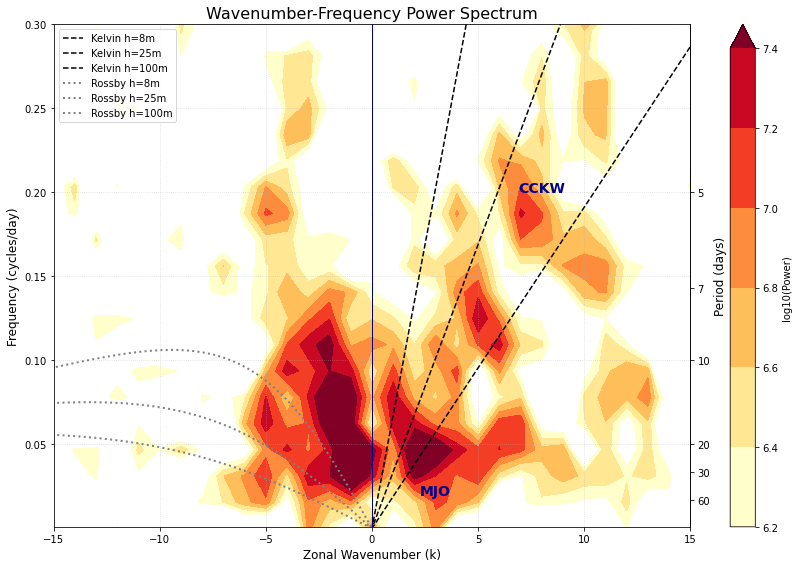

In [212]:
# Run the analysis

k_omega_analysis(ds)

In [213]:
def k_omega_analysis(data_array):
    """
    Performs a wavenumber-frequency (k-ω) analysis on a given xarray DataArray.
    Args:
        data_array (xr.DataArray): The input DataArray to analyze.
                                   Must have 'time' and 'lon' dimensions.
    """
    # --- 1. Data Preparation ---
    data = data_array
    if not all(dim in data.dims for dim in ['time', 'lon']):
        print("Error: DataArray must have 'time' and 'lon' dimensions.")
        return
    data = data.transpose('time', 'lon').copy()

    nt, nx = data.sizes['time'], data.sizes['lon']

    # --- 2. Pre-processing ---
    data_detrended = xr.apply_ufunc(
        signal.detrend,
        data,
        input_core_dims=[['time']],
        output_core_dims=[['time']],
        kwargs={'axis': -1},
        keep_attrs=True
    )
    time_window = xr.DataArray(signal.windows.hann(nt), dims=['time'], coords={'time': data.coords['time']})
    lon_window = xr.DataArray(signal.windows.hann(nx), dims=['lon'], coords={'lon': data.coords['lon']})
    combined_window = time_window * lon_window
    data_windowed = data_detrended * combined_window

    # --- 3. 2D Fourier Transform ---
    sp = fftshift(fft2(data_windowed.values, axes=(0, 1)))
    psd = np.abs(sp)**2

    # --- 4. Create Frequency and Wavenumber Axes ---
    time_step_days = 1 / 8
    k = fftshift(fftfreq(nx)) * nx
    f = fftshift(fftfreq(nt, d=time_step_days))
    
    # -------------------------------------------------------------
    # NEW SECTION: Calculate and remove red noise background
    # Corrected code to broadcast the background spectrum
    # -------------------------------------------------------------
    # Calculate the mean power spectrum along the wavenumber axis (axis=1).
    background_spectrum_1D = np.mean(psd, axis=1)

    # Reshape the 1D spectrum to a column vector (191, 1).
    # This allows it to be broadcast correctly against the 2D psd array (191, 512).
    background_spectrum_column = background_spectrum_1D[:, np.newaxis]

    # Divide the original power spectrum by the broadcasted background.
    epsilon = 1e-12
    psd_ratio = psd / (background_spectrum_column + epsilon)
    # -------------------------------------------------------------

    # --- 5. Plotting ---
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # --- Add Kelvin and Rossby Wave Dispersion Curves ---
    h_eq_values = [8, 25, 90]
    wavenumbers_for_plot = np.linspace(-20, 20, 100)
    
    for h in h_eq_values:
        kelvin_freq = kelvin_dispersion(wavenumbers_for_plot, h)
        ax.plot(wavenumbers_for_plot, kelvin_freq, color='black', linestyle='--', linewidth=1.5, label=f'Kelvin h={h}m')

    for h in h_eq_values:
        rossby_freq = rossby_dispersion(wavenumbers_for_plot, h)
        ax.plot(wavenumbers_for_plot, rossby_freq, color='gray', linestyle=':', linewidth=2, label=f'Rossby h={h}m')
    
    log_psd_ratio = np.log10(psd_ratio)
    
    cmap = plt.get_cmap('seismic')
    levels = np.arange(np.max(log_psd_ratio) - 1, np.max(log_psd_ratio), 0.2)
    levels=arange(1,2.1,.2)
    psd_da = xr.DataArray(
        log_psd_ratio.T,
        dims=['frequency', 'wavenumber'],
        coords={'frequency': f, 'wavenumber': k}
    )
    
    psd_da.plot.contourf(
        ax=ax,
        x='wavenumber',
        y='frequency',
        levels=levels,
        cmap='YlOrRd',
        extend='max',
        cbar_kwargs={'label': 'log10(Power / Background)'}
    )

    # --- 6. Final Plot Adjustments ---
    ax.set_title('Normalized Wavenumber-Frequency Power Spectrum', fontsize=16)
    ax.set_xlabel('Zonal Wavenumber (k)', fontsize=12)
    ax.set_ylabel('Frequency (cycles/day)', fontsize=12)
    ax.text(3, 0.02, 'MJO', color='red', fontsize=14, fontweight='bold', ha='center')
    ax.text(8, 0.2, 'CCKW', color='red', fontsize=14, fontweight='bold', ha='center')
    
    ax.set_xlim(-15, 15)
    ax.set_ylim(0.001, 0.3)

    forward_transform = lambda x: np.where(x != 0, 1/x, np.inf)
    inverse_transform = lambda x: np.where(x != 0, 1/x, np.inf)
    ax2 = ax.secondary_yaxis('right', functions=(forward_transform, inverse_transform))
    ax2.set_ylabel('Period (days)', fontsize=12)
    ax2.set_yticks([2, 3, 5, 7,  10, 20, 30, 60])
    
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.axvline(0, color='darkblue', linewidth=1)
#     # --- Add CCKW Box ---
#     cckw_wavenumber_range = (5, 15)
#     cckw_frequency_range = (0.1, 0.3) # Adjusted frequency range
#     rect = Rectangle((cckw_wavenumber_range [0], cckw_frequency_range [0]),
#     cckw_wavenumber_range [1] - cckw_wavenumber_range [0],
#     cckw_frequency_range [1] - cckw_frequency_range [0],
#     linewidth=1, edgecolor='red', facecolor='none')
#     ax.add_patch(rect)
    plt.tight_layout()
    plt.savefig('normalized_power_spectra.png', dpi=150)
    plt.show()

/var/tmp/pbs.22746178.pbspl1.nas.nasa.gov/ipykernel_92233/3247604729.py:103: RuntimeWarning: divide by zero encountered in true_divide
  inverse_transform = lambda x: np.where(x != 0, 1/x, np.inf)


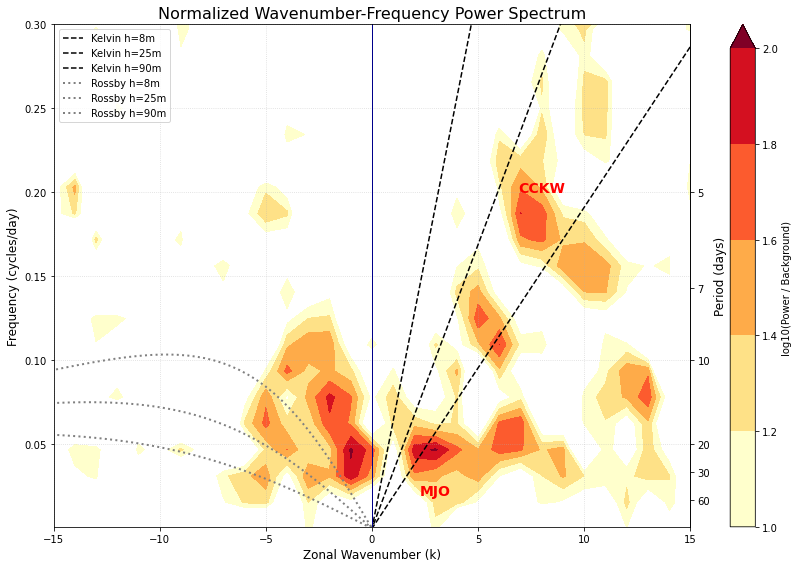

In [214]:
k_omega_analysis(ds)